Initial Setup File for 1st setup

In [1]:
# Check GPU is running or not
import torch
print(torch.cuda.is_available())

True


In [2]:
# Clone Github Repo & Verify it again
!git clone https://github.com/IITAkshayKaleBuilds/Retrieval-Augmented-Generation-LangGraph-Ollama

# check the contents of the cloned repo
%cd Retrieval-Augmented-Generation-LangGraph-Ollama

# check the contents of the RAG_Applications folder
!ls

import sys
sys.path.insert(0, '/content/Retrieval-Augmented-Generation-LangGraph-Ollama')

Cloning into 'Retrieval-Augmented-Generation-LangGraph-Ollama'...
remote: Enumerating objects: 444, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 444 (delta 0), reused 1 (delta 0), pack-reused 439 (from 1)
Receiving objects: 100% (444/444), 12.44 MiB | 14.97 MiB/s, done.
Resolving deltas: 100% (294/294), done.
/content/Retrieval-Augmented-Generation-LangGraph-Ollama
 config.py   LICENSE  'Project Setup'	  README.md
 Figures     main.py   RAG_Applications   requirements.txt


In [3]:
# Set Up Config:
import os
from google.colab import userdata

os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")

if os.environ.get("LANGSMITH_API_KEY"):
  print("LANGSMITH_API_KEY FOUND")
else:
  print("API KEY NOT FOUND")

# Non-sensitive configs
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com/"
os.environ["LANGCHAIN_PROJECT"] = "Retrieval-Augmented-Generation-LangGraph-Ollama"


LANGSMITH_API_KEY FOUND


In [4]:
# Steps to install ollama in runtime of colab
!apt-get update && apt-get install -y zstd

# Install Ollama in Colab
!curl -fsSL https://ollama.com/install.sh | sh

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,497 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,989 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-d

In [5]:
# start Ollama
!nohup ollama serve > ollama.log 2>&1 &

In [6]:
# Pull Embedding Model
!ollama pull qwen3-embedding:0.6b

In [7]:
# Verify Model
!ollama list

NAME                    ID              SIZE      MODIFIED       
qwen3-embedding:0.6b    ac6da0dfba84    639 MB    14 seconds ago    


In [8]:
# Install Project Requirements
!pip install -q -r requirements.txt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 57.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 18.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 10.8 MB/s eta 0:00:0

In [9]:
# Final Check
import langchain
print("OK")

OK


In [10]:
# Advanced RAG - Data Ingestion Pipeline

import os
import hashlib
from pathlib import Path

from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document

from docling.document_converter import DocumentConverter

In [11]:
# configurations
DATA_DIR = "/content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/data"
CHROMA_DIR = "/content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/chroma_financial_db"
COLLECTION_NAME = "financial_docs"
EMBEDDING_MODEL = 'qwen3-embedding:0.6b'
BASE_URL = 'http://127.0.0.1:11434'
LLM_MODEL = "qwen3.5:9b"
DEBUG_PATH = "/content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/debug_logs"

In [12]:
# Create Chroma Vector Store with Ollama Embeddings
embeddings= OllamaEmbeddings(model=EMBEDDING_MODEL, base_url=BASE_URL, num_ctx=8192)

vector_store = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=CHROMA_DIR
)

In [ ]:
# # track the processed files
# existing_docs = vector_store.get(where={"file_hash": {"$ne": ""}}, include=['metadatas'])
# processed_hashes = [m.get('file_hash') for m in existing_docs['metadatas'] if m.get('file_hash')]
# processed_hashes = set(processed_hashes)
# existing_docs

In [13]:
# Data Ingestion Pipeline:
from RAG_Applications.scripts import data_ingestion

data_path = Path(DATA_DIR)
pdf_files = list(data_path.rglob("*.pdf"))

for pdf_path in pdf_files:
    data_ingestion.ingest_docs_in_vectordb(pdf_path)

print("Total documents in DB:", vector_store._collection.count())
#
vector_store._collection.count()


Processing: amazon 10-q q2 2025.pdf


[INFO] 2026-04-09 04:44:22,169 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-09 04:44:22,176 [RapidOCR] download_file.py:68: Initiating download: https://www.modelscope.cn/models/RapidAI/RapidOCR/resolve/v3.8.0/onnx/PP-OCRv4/det/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-04-09 04:44:24,129 [RapidOCR] download_file.py:82: Download size: 4.53MB
[INFO] 2026-04-09 04:44:24,175 [RapidOCR] download_file.py:95: Successfully saved to: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-04-09 04:44:24,178 [RapidOCR] main.py:57: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-04-09 04:44:24,295 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-09 04:44:24,296 [RapidOCR] download_file.py:68: Initiating download: https://www.modelscope.cn/models/RapidAI/RapidOCR/resolve/v3.8.0/onnx/PP-OCRv4/cls/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-04-09 04:44:25,250 [

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Total pages in amazon 10-q q2 2025.pdf: 51


[INFO] 2026-04-09 04:46:37,099 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-09 04:46:37,115 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-04-09 04:46:37,116 [RapidOCR] main.py:57: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-04-09 04:46:37,226 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-09 04:46:37,231 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-04-09 04:46:37,232 [RapidOCR] main.py:57: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-04-09 04:46:37,283 [RapidOCR] base.py:22: Using engine_name: onnxruntime


Processing: amazon 10-q q1 2025.pdf


[INFO] 2026-04-09 04:46:37,317 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_rec_mobile.onnx
[INFO] 2026-04-09 04:46:37,318 [RapidOCR] main.py:57: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_rec_mobile.onnx


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Total pages in amazon 10-q q1 2025.pdf: 50
Total documents in DB: 101


101

In [14]:
#
results = vector_store.search("What is Tesla's revenue for Q1 2024", search_type="similarity")

results

[Document(id='bace5f87-9c4e-49da-95cd-2d86d77a0968', metadata={'source_file': 'amazon 10-q q1 2025.pdf', 'company_name': 'amazon', 'file_hash': 'a06e0bf6d1ba3aac6b82958c381af08b4d476677484170264f6ae8d64fc4fe67', 'doc_type': '10-q', 'fiscal_year': 2025, 'page': 24, 'fiscal_quarter': 'q1'}, page_content="\n\nCash provided by (used in) financing activities was $(1.3) billion and $(47) million for Q1 2024 and Q1 2025. Cash inflows from financing activities resulted from proceeds from short-term debt, and other and long-term debt of $338 million and $2.6 billion for Q1 2024 and Q1 2025. Cash outflows from financing activities resulted from payments of short-term debt, and other, long-term debt, finance leases, and financing obligations of $1.6 billion and $2.6 billion in Q1 2024 and Q1 2025. Property and equipment acquired under finance leases was $42 million and $54 million during Q1 2024 and Q1 2025.\n\nWe had no borrowings outstanding under the two unsecured revolving credit facilities o

In [15]:
# start Ollama
!nohup ollama serve > ollama.log 2>&1 &

# Pull Ollama Model:
!ollama pull qwen3.5:9b


In [16]:
# Verify Model
!ollama list

NAME                    ID              SIZE      MODIFIED       
qwen3.5:9b              6488c96fa5fa    6.6 GB    38 seconds ago    
qwen3-embedding:0.6b    ac6da0dfba84    639 MB    8 minutes ago     


In [ ]:
# Mounting Drive to Save Chroma DB Data
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Zip Chroma DB Local Colab Data To G Drive
#!zip -r "/content/drive/MyDrive/chroma_financial_db.zip" "/content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/chroma_financial_db"


  adding: content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/chroma_financial_db/ (stored 0%)
  adding: content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/chroma_financial_db/42891e49-55fa-441f-b7da-cc2bd1f9ec00/ (stored 0%)
  adding: content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/chroma_financial_db/42891e49-55fa-441f-b7da-cc2bd1f9ec00/index_metadata.pickle (deflated 50%)
  adding: content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/chroma_financial_db/16ebf4a3-4d2d-4452-9800-3918b9124199/ (stored 0%)
  adding: content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/chroma_financial_db/16ebf4a3-4d2d-4452-9800-3918b9124199/link_lists.bin (deflated 86%)
  adding: content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/chroma_financial_db/16ebf4a3-4d2d-4452-9800-3918b9124199/data_level0.bin (deflated 9%)
  adding: content/Retrieval-Augmented-Generation-LangGraph-Ol

In [ ]:
# UnZIP Them After
#!unzip "/content/drive/MyDrive/chroma_financial_db.zip" -d "/content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/chroma_financial_db"

===========================================================================================================

**ADAPTIVE RAG** =>
Three routing paths:
1. **Financial Documents (vectorstore)** -> Self-RAG flow
(retrieve -> grade -> generate -> check hallucinations -> check answer quality)
2. **Employee Database (sql_database)** -> **SQL agent** -> query execution -> generate -> check Local DB
3. **General Knowledge (web_search)** -> **Web search** -> generate -> search Web Online

===========================================================================================================

Starting Retrieval Pipeline =>

In [17]:
from typing_extensions import TypedDict
from typing import Annotated, List
import operator
import os

from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

from langchain_community.utilities import SQLDatabase
from pydantic import BaseModel, Field

from langchain.agents import create_agent

In [20]:
# Importing Local Python Files
import sys
import os
import json
import re
sys.path.append('/content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications')

from scripts.utils import robust_json_parser
from scripts import my_tools, mysql_tools
from scripts.nodes import (
    retrieve_node,
    grade_documents_node,
    generate_node,
    transform_query_node,
    should_generate,
    check_answer_quality,
    get_latest_user_query
)


================================== Ai Message ==================================

Hello! I'm doing well, thank you for asking. How about you? Is there anything I can help you with today?


ModuleNotFoundError: No module named 'utils'

In [ ]:
llm = ChatOllama(model=LLM_MODEL, base_url=BASE_URL, temperature=0.0)

In [ ]:
# =============================================================================
# Pydantic Schemas for Structured Outputs
# =============================================================================
class RouterQuery(BaseModel):
    datasource: str = Field(description="Datasource to route query to: 'retrieve' for financial documents, 'sql_agent' for employee information, 'web_search' for general knowledge")

In [ ]:
class AgentState(TypedDict):

    messages: Annotated[list, operator.add]
    retrieved_docs: str
    rewritten_queries: List[str]
    retry_count: int

In [ ]:
    # -----------------------------------------------------------------------------
    # Query Analysis & Routing
    # -----------------------------------------------------------------------------

    # Route query to appropriate datasource
from RAG_Applications.scripts.utils import robust_json_parser
from json import JSONDecodeError # Added import


def route_question(state: AgentState):

        query = get_latest_user_query(state['messages'])

        print(f"[QUERY] {query}")

        system_prompt = """You are an expert at routing user questions to the appropriate datasource.

                        **Datasources:**
                        1. **retrieve**: Financial documents (10-K, 10-Q, 8-K reports) about companies like Amazon, Apple, Google
                        - Questions about: revenue, operating income, cash flow, segments, financial metrics, quarterly/annual performance
                        - Examples: "What was Amazon's revenue in 2023?", "Compare Apple vs Google Q1 2024 revenue"

                        2. **sql_agent**: Employee database with structured data
                        - Questions about: employees, departments, salaries, managers, job titles, hiring dates
                        - Examples: "Who is the CFO?", "List employees in Finance", "What is John's salary?"

                        3. **web_search**: General knowledge outside our databases
                        - Questions about: current events, general facts, topics unrelated to our data
                        - Examples: "What is inflation rate?", "How does RAG work?", "Capital of France?"

                        **Decision Logic:**
                        - Check for financial terms (revenue, income, cash flow, quarterly, annual, 10-K, 10-Q) -> retrieve
                        - Check for company names in our database (amazon, apple, google) -> retrieve
                        - Check for employee-related terms (employee, department, salary, CFO, manager) -> sql_agent
                        - Everything else -> web_search
                        Respond in JSON format.

                        Format:
                        {
                            "datasource": "retrieve" OR "sql_agent" OR "web_search"
                        }
                        Return Only valid Json.
                        """

        messages = [SystemMessage(system_prompt), HumanMessage(query)]

        response = llm.invoke(messages)
        raw_llm_output = response.content
        print("RAW LLM OUTPUT:", raw_llm_output)

        decision = "retrieve" # Default decision
        try:
            parsed = robust_json_parser(raw_llm_output)
            if parsed:
                decision = parsed.get("datasource", "retrieve")
        except JSONDecodeError as e:
            print(f"JSONDecodeError: Could not parse LLM output: {raw_llm_output}. Error: {e}")
            decision = "retrieve" # Fallback to retrieve on parsing error
        except Exception as e: # Catch other potential errors during parsing
            print(f"An unexpected error occurred during LLM output parsing: {e}")
            decision = "retrieve"


        decision = decision.lower().strip()

        valid_routes = ["retrieve", "sql_agent", "web_search"]

        if decision not in valid_routes:
            print(f"Invalid route '{decision}', defaulting to retrieve")
            decision = "retrieve"

        print(f"[DECISION] Routing to {decision}")

        return decision

In [ ]:
route_question({'messages': [HumanMessage('what is the revenue of google?')]})

In [ ]:
# -----------------------------------------------------------------------------
# SQL Database Path (Agent-based)
# -----------------------------------------------------------------------------

# SQL agent that handles the entire workflow
def sql_agent_node(state: AgentState):

    query = get_latest_user_query(state['messages'])

    system_prompt = system_prompt = f"""You are an expert SQL analyst working with an employees database.

                    Database Schema:
                    {mysql_tools.SCHEMA}

                    Your workflow for answering questions:
                    1. Use `get_database_schema` first to understand available tables and columns (if needed)
                    2. Use `generate_sql_query` to create SQL based on the question
                    3. Use `execute_sql_query` to run the validated query
                    4. If there's an error, use `fix_sql_error` to correct it and try again (up to 3 times)

                    Rules:
                    - Always follow the workflow step by step
                    - If a query fails, use the fix tool and try again
                    - Provide clear, informative answers
                    - Be precise with table and column names
                    - Handle errors gracefully and try to fix them
                    - If you fail after 3 attempts, explain what went wrong

                    Available tools:
                    - get_database_schema: Get table structure info
                    - generate_sql_query: Create SQL from question
                    - execute_sql_query: Run the query
                    - fix_sql_error: Fix failed queries

                    Remember:
                    -Always validate queries before executing them for safety.
                    - Provide clear, formatted results in MARKDOWN
                    - Use tables for structured data"""

    agent = create_agent(model=llm, tools=mysql_tools.ALL_SQL_TOOLS, system_prompt=system_prompt)

    result = agent.invoke({'messages': [HumanMessage(query)]})

    print(f"[SQL] Agent completed!")

    return {'messages': result['messages']}

In [ ]:
# -----------------------------------------------------------------------------
# Web Search Path (Agent-based)
# -----------------------------------------------------------------------------

# Web search agent that handles the entire workflow

def web_search_node(state: AgentState):

    query = get_latest_user_query(state['messages'])

    system_prompt = """You are a helpful web search assistant. Be concise and accurate.

                    **Workflow:**
                    1. Use web_search tool to find relevant information
                    2. Synthesize information from multiple sources
                    3. Provide a clear, comprehensive answer

                    **OUTPUT FORMAT:**
                    Write a clear answer (150-250 words) in **MARKDOWN** format:
                    - Use ## headings for sections
                    - Use **bold** for emphasis
                    - Use bullet points for key facts

                    **GUIDELINES:**
                    - Base your answer on web search results
                    - Synthesize information from multiple sources
                    - Be factual and objective"""

    agent = create_agent(model=llm, tools=[my_tools.web_search], system_prompt=system_prompt)

    result = agent.invoke({'messages': [HumanMessage(query)]})

    print(f"[WEB] Agent is completed!")

    return {'messages': result['messages']}

In [ ]:
#### Add short term memory

from langgraph.checkpoint.sqlite import SqliteSaver
import os
import sqlite3

db_name = "db/checkpoints.db"

os.makedirs('db', exist_ok=True)

In [ ]:
# =============================================================================
# Build Graph
# =============================================================================

# Build Adaptive RAG graph with three routing paths


def create_adaptive_rag():

    builder = StateGraph(AgentState)

    # add nodes
    builder.add_node('retrieve', retrieve_node)
    builder.add_node('grade_documents', grade_documents_node)
    builder.add_node('generate', generate_node)
    builder.add_node('transform_query', transform_query_node)

    # add adaptive specific nodes
    builder.add_node('sql_agent', sql_agent_node)
    builder.add_node('web_search', web_search_node)

    # define edges
    # builder.add_edge(START, 'retrieve')
    builder.add_conditional_edges(START, route_question, ['retrieve', 'sql_agent', 'web_search'])

    builder.add_edge('retrieve', 'grade_documents')
    builder.add_edge('transform_query', 'retrieve')

    # conditional edges
    builder.add_conditional_edges('grade_documents', should_generate, ['transform_query', 'generate'])
    builder.add_conditional_edges('generate', check_answer_quality, ['generate', END, 'transform_query'])

    builder.add_edge('sql_agent', END)
    builder.add_edge('web_search', END)

    conn = sqlite3.connect(db_name, check_same_thread=False)
    checkpointer = SqliteSaver(conn)
    graph = builder.compile(checkpointer=checkpointer)

    return graph

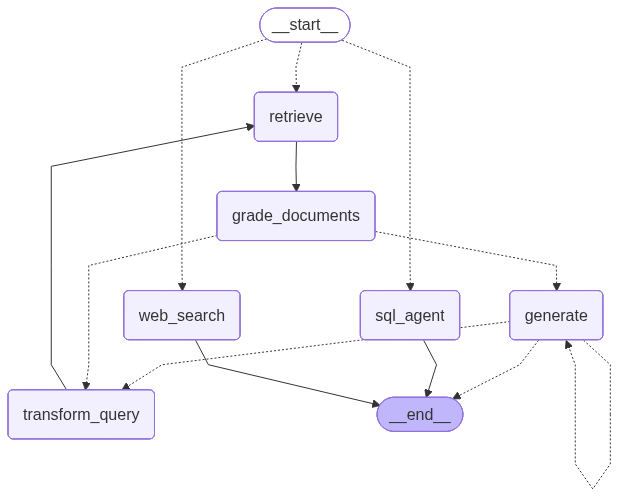

In [ ]:
agent = create_adaptive_rag()
agent

In [ ]:
config = {'configurable': {'thread_id': 'demo1'}}

query = "show me amazon's revenue in 2024?"
result = agent.invoke({'messages': [HumanMessage(query)], 'retry_count': 0}, config=config)
print(result['messages'][-1].content)
result['messages'][-1].pretty_print()

[QUERY] show me amazon's revenue in 2024?
[DECISION] Routing to retrieve
[RETRIEVE] fetching documents...
[RETRIEVE] Query 1: show me amazon's revenue in 2024?

[TOOL] retrieve_docs called
[QUERY] show me amazon's revenue in 2024?


OutputParserException: Invalid json output: 
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 

In [ ]:
result['messages'][-1].pretty_print()

In [ ]:
result = agent.invoke({'messages': [HumanMessage("What is the latest AI news?")]}, config=config)
print(result['messages'][-1].content)

In [ ]:
result = agent.invoke({'messages': [HumanMessage("How many employees are there?")]}, config=config)
print(result['messages'][-1].content)